<a href="https://colab.research.google.com/github/70ommy/Variational-Autoencoder-VAE-project/blob/main/Variational_Autoencoder_(VAE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project implementation: Variational Autoencoder (VAE)

**Student:** Tommaso Godino  
**ID:** 535412

### Aim of the model
This notebook presents the implementation of the required solution for the exam task. The objective is to build a deep neural network that can encode images into a probabilistic latent representation and then reconstruct or generate new images. The structure closely follows the example code provided and respects the step-by-step order outlined in the exam instructions.


INFO:
- The notebook takes around 5 minutes to run
- Any change in the proposed model during the exam will be marked by: <font color="red">**CHANGE**</font>.


In [1]:
!pip install keras
!pip install tensorflow


In [2]:
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras as K
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle as pk
from keras import ops # provides compatibility across multiple backends
import itertools


In [3]:
!wget https://raw.githubusercontent.com/70ommy/Dataset_images/refs/heads/main/input_data.pkl

--2025-07-22 18:02:13--  https://raw.githubusercontent.com/70ommy/Dataset_images/refs/heads/main/input_data.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5495252 (5.2M) [application/octet-stream]
Saving to: ‘input_data.pkl’

input_data.pkl      100%[===================>]   5.24M  --.-KB/s    in 0.02s   

2025-07-22 18:02:15 (291 MB/s) - ‘input_data.pkl’ saved [5495252/5495252]



In [4]:
with open('input_data.pkl', 'rb') as f:
    dd = pk.load(f)

data = dd['data']
labels = dd['labels']

**I'll cut 25% of the total dataset** to save cmputational resources, in order to stay under the 5 minutes limit

In [5]:
keep_len = int(len(data) * 0.75)
data = data[:keep_len]
labels = labels[:keep_len]


In [6]:
print(type(data), type(labels))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [7]:
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (5250, 28, 28)
Labels shape: (5250,)


## 1. Model

The chosen Model of choice: **VARIATIONAL AUTOENCODER (VAE)**

Model Change:
- **The depth of the model is set to 2 for limit in computational resources**(time limit), and it will not be a hyperparameter of the model for this reason. <font color="red">**CHANGE**</font>

In [8]:
IMAGE_WIDTH = 28
IMAGE_HEIGHT = 28
IMAGE_CHANNELS = 1
NUM_CLASSES = 10

# 2. INPUT and Preprocessing

**IMAGES PREPROCESSING**
- Since The dataset is composed by grayscale images, pixel values are normalized from [0, 255] to [0, 1]

- As I pointed out in the exam, due to the time limit for the model, I decide to not implement Image Augmentation. By doing that, I will speed up the process of training

**CLASSES PREPROCESSING**

The class labels will be used to enrich the probabilistic latent space with additional information.

- They will be transformed into a format similar to one-hot encoding, but applied as additional channels to the image.

**INPUT SHAPE**
- The final input will have the shape [batch_size, 28, 28, 11] (1 channel for the grayscale image + 10 channels for the class labels).

In [9]:
def preprocess_data(images, labels):

    # Pixel normalization in range [0,1]
    images = images.astype("float32") / 255.0
    # adding greyscale channel
    images = np.expand_dims(images, -1)

    # conversion of label in one-hot format
    labels_one_hot = keras.utils.to_categorical(labels, NUM_CLASSES)

    print("Images shape:", images.shape)
    print("Labels shape:", labels_one_hot.shape)

    return images, labels_one_hot

def create_conditional_input(images, labels_one_hot):

    # creation of tensor (num_samples, 28, 28, 10) for the labels channels
    label_channels = np.zeros((images.shape[0], IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CLASSES))
    for i in range(images.shape[0]):
      label_channels[i] = np.ones((IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CLASSES)) * labels_one_hot[i]

    # concatenation of the greyscale channel with the labels channels (1+10)
    conditional_images = np.concatenate([images, label_channels], axis=-1)
    print(conditional_images.shape)

    return conditional_images

data_temp, labels_temp = preprocess_data(data, labels)
data_preprocessed = create_conditional_input(data_temp, labels_temp)

Images shape: (5250, 28, 28, 1)
Labels shape: (5250, 10)
(5250, 28, 28, 11)


After Normalization I do the train/validation/test split to avoid any type of leakage. I will split the dataset manually

In [10]:
temp_val = 0.15
temp_test = 0.15

n_total = data_preprocessed.shape[0]
val_num = int(n_total * temp_val)
test_num = int(n_total * temp_test)

# shuffle
indices = np.arange(n_total)
np.random.seed(42)
np.random.shuffle(indices)

data = data_preprocessed[indices]

# split
x_val = data[:val_num]


x_test = data[val_num:val_num+test_num]

x_train = data[val_num+test_num:]


INPUT_SHAPE = tuple(x_train.shape[1:])

print(f'Train:      {x_train.shape}')
print(f'Validation: {x_val.shape}')
print(f'Test:       {x_test.shape}')
print(INPUT_SHAPE)


Train:      (3676, 28, 28, 11)
Validation: (787, 28, 28, 11)
Test:       (787, 28, 28, 11)
(28, 28, 11)


## 3. Model Configuration

The VAE consists of an Encoder, a Decoder, and a specialized `Sampling` layer.
**Conceptual Outline:** `Input Image` -> **[Encoder]** -> `Latent Distribution` -> **[Sampling]** -> `Latent Vector` -> **[Decoder]** -> `Reconstructed Image`

In [11]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = K.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = K.random.normal(shape=(batch, dim), seed=self.seed_generator,
                                  mean=0, stddev=1,)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

## 3.a. Image Projection (ENCODER)

A series of blocks composed of convolutional layers, ReLU activation (to prevent vanishing gradients), Batch Normalization (to speed up training), and Max-Pooling (to select the most important features). It reduces the image's dimensionality through convolutional and pooling layers, finally outputting the mean (`z_mean`) and log-variance (`z_log_var`) of the learned distribution.

In [12]:
def build_encoder(input_shape, latent_dim, kernel_size):

    inputs = keras.Input(shape=input_shape)

    #first block
    x = layers.Conv2D(32, kernel_size, activation="relu", strides=1, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding = 'same')(x)

    #second block
    x = layers.Conv2D(64, kernel_size, activation="relu", strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding = 'same')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

    return encoder

## 3.c. Modello del Decoder



The decoder is symmetric to the encoder and performs upscaling of the compressed image. It takes the latent vector z (sampled from the distribution defined by z_mean and z_log_var) and upsamples it using "up-convolutions" (2D transposed convolutions) with a 2x2 kernel and stride 2 to double the image dimensions, followed by standard convolutional layers to reconstruct the image.

In [13]:
def build_decoder(latent_dim, kernel_size):

    # The model's only input is the sampled latent vector.
    latent_inputs = keras.Input(shape=(latent_dim,), name='z_input')

    # Upsampling architecture to transform the vector into a feature map.
    x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)

    #first block
    x = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(x)
    x = layers.Conv2D(64, kernel_size, activation= 'relu', padding="same")(x)
    x = layers.BatchNormalization()(x)

    #second block
    x = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(x)
    x = layers.Conv2D(32, kernel_size, activation = 'relu', padding="same")(x)
    x = layers.BatchNormalization()(x)

    # Final Output Construction (28, 28, 11) from a single pipeline

    # Step 1: Generate the image channel (1 channel)
    image_channel = layers.Conv2D(
        1,
        kernel_size=3,
        activation="sigmoid",
        padding="same",
        name="image_channel"
    )(x)

    # Step 2: Generate the class channels (10 channels)
    class_channels = layers.Conv2D(
        NUM_CLASSES,
        kernel_size=3,
        activation="softmax",
        padding="same",
        name="class_channels"
    )(x)

    # Step 3: Concatenate the two parts to form a single output tensor
    decoder_outputs = layers.concatenate(
        [image_channel, class_channels],
        name="final_output"
    )

    # The model has a single input and a single output.
    decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")



    return decoder

---
## 3.d. New Images Generation
To generate new images, the encoder is no longer used. Instead, a random latent vector z is sampled from a standard normal distribution N(0, I) and fed into the trained decoder. The decoder then transforms this latent code into a synthetic image that is consistent with the patterns learned during training, but dofferent from the other images in the original dataset.


---
## 3.e Hyperparameters

**RANDOM GRID SEARCH HYPERPARAMETERS**


For my specific case, due to the necessity to run the model under 5 minutes, I will define the grid search fo small hyperparameters (in order to speed up the process), moreover I will increase the number of epochs for each rando sample of parameters and decrease the number of random combinations to try.

In a real scenario, the ideal number of combination to try should be greater, also the values of the hyperparameters to explore should be greater too




As an addition for the hyperparameter I need to add  'MONITOR' for the early stopping, otherwise the function early stop won't know what to track in order to decide weather to stop or not <font color="red">**CHANGE**</font>


In [20]:
# 2. HYPERPARAMETER SPACE DEFINITION
# Define the range of values for each hyperparameter you want to tune.
param_grid = {
    'LATENT_DIM': [4, 8, 16],
    'BETA': [1, 2],
    'LEARNING_RATE': [5e-4, 1e-4, 5e-5],
    'BATCH_SIZE': [64],
    'OPTIMIZER': ['Adam'],
    'PATIENCE': [4, 5],
    'KERNEL_SIZE': [3, 4],
    'MONITOR': ['val_total_loss', 'val_reconstruction_loss'], # Changed val_loss to val_total_loss
    'MIN_DELTA': [0.001, 0.01, 0],
}

# Number of random combinations to try
NUM_TRIALS = 5

print(f"---Prepared Randomized Grid Search for {NUM_TRIALS} Trials ---")

def random_search_vae(vae_model_class, INPUT_SHAPE, param_grid, x_train, x_val, samples=NUM_TRIALS):
    combos = list(itertools.product(*param_grid.values()))
    sampled_combos = random.sample(combos, min(samples, len(combos)))
    configs = [dict(zip(param_grid.keys(), c)) for c in sampled_combos]
    best_val_loss = np.inf
    best_cfg = None

    for idx, cfg in enumerate(configs):
        print(f"\n=== Training config {idx+1}/{len(configs)} ===")
        print("Config:", cfg)

        # model with current configuration
        # Pass the builder functions, not the instantiated models
        vae_model = vae_model_class(INPUT_SHAPE, cfg['LATENT_DIM'], build_encoder, build_decoder, cfg['KERNEL_SIZE'], cfg['BETA'])

        # Compile the model
        # The optimizer is defined within the VAE class's compile method
        if cfg['OPTIMIZER'] == 'Adam':
            optimizer = keras.optimizers.Adam(learning_rate=cfg['LEARNING_RATE'])
        elif cfg['OPTIMIZER'] == 'RMSprop':
            optimizer = keras.optimizers.RMSprop(learning_rate=cfg['LEARNING_RATE'])
        else: # SGD
            optimizer = keras.optimizers.SGD(learning_rate=cfg['LEARNING_RATE'])


        vae_model.compile(optimizer=optimizer)

        # Definition for early stopping
        early_stopping = keras.callbacks.EarlyStopping(
            monitor=cfg['MONITOR'],
            patience=cfg['PATIENCE'],
            min_delta=cfg['MIN_DELTA'],
            verbose=1,
            mode='min'
        )

        #training for model
        history = vae_model.fit(
            x_train, x_train,
            epochs=200,
            batch_size=cfg['BATCH_SIZE'],
            validation_data=(x_val, x_val),
            callbacks=[early_stopping],
            verbose=1
        )

        # I'll get the best validation loss for the run
        monitor_metric = cfg['MONITOR']
        # Check if the exact monitor_metric is in history, otherwise try 'val_total_loss'
        if monitor_metric in history.history:
            final_val_loss = min(history.history[monitor_metric])
        elif 'val_total_loss' in history.history: # Added fallback to val_total_loss
            final_val_loss = min(history.history['val_total_loss'])
        else:
            # If neither is available, use the first metric in history as a fallback (shouldn't happen with the current VAE class)
            print("Warning: Could not find specified monitor metric or 'val_total_loss'. Using the first available validation metric.")
            val_metrics = [key for key in history.history.keys() if key.startswith('val_')]
            if val_metrics:
                final_val_loss = min(history.history[val_metrics[0]])
                monitor_metric = val_metrics[0] # Update monitor_metric for printing
            else:
                 # No validation metrics found, something is wrong
                 print("Error: No validation metrics found in history.")
                 final_val_loss = np.inf # Set to infinity to avoid selecting this config


        print(f"Best {monitor_metric} for this config: {final_val_loss:.4f}")

        if final_val_loss < best_val_loss:
            best_val_loss = final_val_loss
            best_cfg = cfg
            print(f"*** New best model found! ***")

    print("\n=== Best Results Summary ===")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print("Best configuration:", best_cfg)
    return best_cfg

---Prepared Randomized Grid Search for 5 Trials ---


#4: OUTPUT
The output layer of the decoder is a `Conv2D` layer with:
- **filters**: `11` because the output will be a image `28,28,11` as the input (1 channel for the grey and 10 for the classes). An important point is that the model **will not** classify the reconstructed images, the class-channels are given to enrich the latent space, and then theya re built back, but not classification is done
- **No activation function**: In the exam I didn't mention an activation function for the output layer (image channel and classes channel)

# 5. LOSS
<font color="red">**CHANGE**</font> with respect to exam: In the exam, I **mistakenly used only the Kullback-Leibler (KL) Divergence[link text](https://)** as the reconstruction loss.  
While KL_divergence is part of the complete loss, it's not correct alone.

The loss function for a **VAE** consists of two main components, which reflect its **probabilistic generative nature**:

---

**1. Reconstruction Loss**  
For VAEs, the reconstruction term is derived from the assumption that pixels are generated from a Gaussian distribution. Under this assumption, the appropriate reconstruction loss is the **Mean Squared Error (MSE)**:

$$
\mathcal{L}_{\text{recon}} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2
$$

Where:
- $x_i$ is the original pixel value,
- $\hat{x}_i$ is the reconstructed pixel value,
- $N$ is the total number of pixels.


**2. Kullback-Leibler (KL) Divergence**  
This term ensures that the latent space distribution learned by the encoder remains close to a prior distribution (usually a standard normal $\mathcal{N}(0, I)$):

$$
\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2 \right)
$$

Where:
- $\mu_j$ and $\sigma_j$ are the predicted mean and standard deviation for latent dimension $j$,
- $d$ is the dimensionality of the latent space.

This term is **crucial** for enabling the model to generalize and generate new data by sampling from the latent space.

---

**3. Total Loss Function**

The final VAE loss combines the two components:

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}} + \beta \cdot \mathcal{L}_{\text{KL}}
$$

Where:
- $\beta$ is a hyperparameter that balances reconstruction accuracy with latent space regularization.  
  In the standard VAE, $\beta = 1$, but it can be tuned (e.g., in $\beta$-VAEs) to control disentanglement.

---

**Summary**  
My initial response mistakenly applied a loss formulation which was not complete.

A correct VAE implementation must:
- Use **MSE** for reconstruction (derived from Gaussian likelihood),
- Include the **KL divergence** for latent regularization,
- Combine both in a total loss that supports both reconstruction and generative capabilities.

This correction reflects a deeper understanding of **why** these loss terms are used in VAEs and how they relate to the model’s probabilistic foundations.

In [18]:
class VAE(keras.Model):
    """
    Classe VAE che usa il decoder incondizionato con augmentazione (rotazione + zoom).
    """
    def __init__(self, input_shape, latent_dim, encoder_builder, decoder_builder, kernel, beta, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.input_shape = input_shape
        self.latent_dim = latent_dim
        self.kernel_size = kernel
        self.beta = beta
        self.encoder = encoder_builder(self.input_shape, self.latent_dim, self.kernel_size)
        # Pass the latent_dim to the decoder builder
        self.decoder = decoder_builder(self.latent_dim, self.kernel_size)

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    @tf.function
    def train_step(self, data): # Revert to accepting a single data argument

        x, y = data # Unpack data into x and y

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)

            # Calcola la loss di ricostruzione sull'intero tensore 28x28x11
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(y - reconstruction), axis=(1, 2, 3))
            )

            # KL divergence (media sul batch)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            # Total loss
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
  # method to encode images
    def getEncodedImage(self, image):
          encoded_image = self.encoder.predict(image)
          return encoded_image
  # method to decode images
    def getDecodedImage(self, encoded_imgs):
        decoded_image = self.decoder.predict(encoded_imgs)
        return decoded_image

    def call(self, input):
      _,_,z = self.encoder(input)
      return self.decoder(z)



    def test_step(self, data): # Revert to accepting a single data argument
      if isinstance(data, tuple):
        x, y = data # Unpack data into x and y
      else:
        x = data # If only input is passed
        y = data # Assume target is same as input

      z_mean, z_log_var, z = self.encoder(x)
      reconstruction = self.decoder(z)

      # computing reconstruction loss
      reconstruction_loss = tf.reduce_mean(
          tf.reduce_sum(tf.square(y - reconstruction), axis=(1, 2, 3))
      )

      # KL divergence
      kl_loss = -0.5 * tf.reduce_mean(
          tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
      )

      # Total loss
      total_loss = reconstruction_loss + self.beta * kl_loss

      self.total_loss_tracker.update_state(total_loss)
      self.reconstruction_loss_tracker.update_state(reconstruction_loss)
      self.kl_loss_tracker.update_state(kl_loss)

      return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# 6. Model Evaluation

The model is evaluated through a comprehensive process that includes hyperparameter tuning, final training, and **quantitative**   **assessment**

(Plus, I'll plot the reconstructed images just for a visual feedback from the model, the real evaluation is done in a quantitative way).

### Hyperparameter Search Execution
I execute the random search defined in Point 3e to find the best hyperparameters using a validation set.

In [21]:
final_config =random_search_vae(vae_model_class = VAE,
                                INPUT_SHAPE = INPUT_SHAPE,
                                param_grid = param_grid,
                                x_train = x_train,
                                x_val = x_val)


=== Training config 1/5 ===
Config: {'LATENT_DIM': 8, 'BETA': 1, 'LEARNING_RATE': 0.0001, 'BATCH_SIZE': 64, 'OPTIMIZER': 'Adam', 'PATIENCE': 5, 'KERNEL_SIZE': 3, 'MONITOR': 'val_total_loss', 'MIN_DELTA': 0.001}
Epoch 1/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - kl_loss: 0.0245 - reconstruction_loss: 835.9424 - total_loss: 835.9670 - val_kl_loss: 0.2760 - val_reconstruction_loss: 814.0006 - val_total_loss: 814.2766
Epoch 2/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 1.1896 - reconstruction_loss: 806.9105 - total_loss: 808.1000 - val_kl_loss: 10.4178 - val_reconstruction_loss: 776.7228 - val_total_loss: 787.1406
Epoch 3/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - kl_loss: 10.3683 - reconstruction_loss: 761.9053 - total_loss: 772.2736 - val_kl_loss: 6.9983 - val_reconstruction_loss: 750.9916 - val_total_loss: 757.9899
Epoch 4/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - kl_loss: 8.9531 - reconstruction_loss: 737.8590 - total_loss: 746.8121 - val_kl_loss: 7.7884 - val_

## Definitive Model

Now that I found the best hyperparameters, I will define the final model and train.


In [23]:
best_configutions = {
    'LATENT_DIM': 16,
    'BETA': 1,
    'LEARNING_RATE': 0.0001,
    'BATCH_SIZE': 64,
    'OPTIMIZER': 'Adam',
    'PATIENCE': 4,
    'KERNEL_SIZE': 3,
    'MONITOR': 'val_total_loss',
    'MIN_DELTA': 0,
}

LATENT_DIM = best_configutions.get('LATENT_DIM', 16)
BETA = best_configutions.get('BETA', 0.5)
LEARNING_RATE = best_configutions.get('LEARNING_RATE', 0.001)
BATCH_SIZE = best_configutions.get('BATCH_SIZE', 64)
OPTIMIZER = best_configutions.get('OPTIMIZER', 'RMSprop')
PATIENCE = best_configutions.get('PATIENCE', 3)
KERNEL_SIZE = best_configutions.get('KERNEL_SIZE', 3)
MONITOR = best_configutions.get('MONITOR', 'val_reconstruction_loss')
MIN_DELTA = best_configutions.get('MIN_DELTA', 0)
EPOCHS = 200  # Not present in best_configutions, so set explicitly

print("\n--- Training Final Model with Best Hyperparameters ---")
print(f"Config: {best_configutions}")

#I'm going to train with the whole train set (train+validation)
x_train_final = np.concatenate([x_train, x_val], axis=0)

final_vae = VAE(INPUT_SHAPE, LATENT_DIM, build_encoder, build_decoder, KERNEL_SIZE, BETA)

if OPTIMIZER == 'Adam':
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
else:
    optimizer = keras.optimizers.RMSprop(learning_rate=LEARNING_RATE)

final_vae.compile(optimizer=optimizer)
final_vae.encoder.summary() # Corrected: Call summary on the instantiated encoder model
final_vae.decoder.summary() # Corrected: Call summary on the instantiated decoder model

callbacks = []
if 'PATIENCE' in best_configutions and 'MONITOR' in best_configutions:
    callbacks.append(
        keras.callbacks.EarlyStopping(
            monitor=MONITOR,
            patience=PATIENCE,
            min_delta=MIN_DELTA,
            verbose=1,
            mode='min'
        )
    )

history = final_vae.fit(
    x_train_final, x_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, x_test),
    callbacks=None)


--- Training Final Model with Best Hyperparameters ---
Config: {'LATENT_DIM': 16, 'BETA': 1, 'LEARNING_RATE': 0.0001, 'BATCH_SIZE': 64, 'OPTIMIZER': 'Adam', 'PATIENCE': 4, 'KERNEL_SIZE': 3, 'MONITOR': 'val_total_loss', 'MIN_DELTA': 0}


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 28, 28,    │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 28, 28,    │      3,200 │ input_layer_16[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_32… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 3136)      │          0 │ max_pooling2d_33… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 16)        │     50,192 │ flatten_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │        272 │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │        272 │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_16         │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 72,816 (284.44 KB)

 Trainable params: 72,624 (283.69 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_input             │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 3136)      │     53,312 │ z_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_16          │ (None, 7, 7, 64)  │          0 │ dense_33[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_32 │ (None, 14, 14,    │     16,448 │ reshape_16[0][0]  │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 14, 14,    │     36,928 │ conv2d_transpose… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_66[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_33 │ (None, 28, 28,    │      8,224 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 28, 28,    │      9,248 │ conv2d_transpose… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_67[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_channel       │ (None, 28, 28, 1) │        289 │ batch_normalizat… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_channels      │ (None, 28, 28,    │      2,890 │ batch_normalizat… │
│ (Conv2D)            │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_output        │ (None, 28, 28,    │          0 │ image_channel[0]… │
│ (Concatenate)       │ 11)               │            │ class_channels[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,723 (498.92 KB)

 Trainable params: 127,531 (498.17 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - kl_loss: 0.1274 - reconstruction_loss: 833.2327 - total_loss: 833.3601 - val_kl_loss: 1.1027 - val_reconstruction_loss: 805.5196 - val_total_loss: 806.6221
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 2.1327 - reconstruction_loss: 799.7769 - total_loss: 801.9097 - val_kl_loss: 7.5008 - val_reconstruction_loss: 774.3845 - val_total_loss: 781.8853
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 8.2470 - reconstruction_loss: 758.2047 - total_loss: 766.4517 - val_kl_loss: 7.6401 - val_reconstruction_loss: 737.3483 - val_total_loss: 744.9883
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 9.5215 - reconstruction_loss: 722.0940 - total_loss: 731.6155 - val_kl_loss: 10.4927 - val_reconstruction_loss: 707.4216 - val_total_loss: 717.9144
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 12.6449 - reconstruction_loss: 686.3824 - total_loss: 699.0272 - val_kl_loss: 15.4020 - val_r


**QUANTITATIVE EVALUATION**

The primary quantitative evaluation of the model will be based on the Evidence Lower Bound (ELBO), calculated on the unseen test set.

I decided to use the ELBO (and not only the MSE) for evaluation because it is the same
objective function that the VAE minimizes during training. This provides
a holistic measure of performance, as it simultaneously accounts for both
the reconstruction quality (through the Mean Squared Error) and the
quality of the latent space organization (through the KL divergence).

Moreover, in the exam I didn't define what ELBO is and why it is
fundamental for VAEs.

What is the ELBO?

In Variational Autoencoders, we approximate the complex true posterior p(z|x) with a simpler, learnable distribution, q_ϕ(z|x). The Evidence Lower Bound (ELBO) is a lower bound on the log-likelihood of the data, log p(x). By maximizing the ELBO, we make our approximation q_ϕ(z|x) as close as possible to the true posterior.

ELBO consists of two key terms:

- RECONSTRUCTION TERM
      This term measures how well the decoder can reconstruct the original
      input image 'x' from its latent representation 'z' (in my case the MSE).

- REGULARIZATION TERM (KL DIVERGENCE)
      This is the Kullback-Leibler (KL) divergence between the distribution
      learned by the encoder, q(z|x), and a simple prior distribution, p(z)
      (typically a standard normal distribution).
      This term acts as a regularizer, forcing the latent space to be
      well-structured and continuous, which is crucial for the model's
      ability to generate new, realistic samples.


In [54]:
def evaluate_elbo_on_test_set(model, test_data):
    """
    Calculates the Evidence Lower Bound (ELBO) on the clean test set.
    """
    print("Evaluating model performance on the clean test set...")

    # Encode and decode without augmentation
    z_mean, z_log_var, z = model.encoder.predict(test_data, verbose=0)
    reconstructions = model.decoder.predict(z, verbose=0)


    # Ensure test_data is float32 to prevent dtype errors
    test_data_float32 = tf.cast(test_data, dtype=tf.float32)

    reconstruction_loss = tf.reduce_mean(
        tf.reduce_sum(tf.square(test_data_float32 - reconstructions), axis=(1, 2, 3))
    )

    # KL divergence (media sul batch)
    kl_loss = -0.5 * tf.reduce_mean(
        tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
    )


    # ELBO = negative total loss (since we maximize ELBO)
    total_loss = reconstruction_loss + model.beta * kl_loss
    elbo = -total_loss

    # Return numerical values
    results = {
        "ELBO": float(elbo.numpy()),
        "Reconstruction Loss": float(reconstruction_loss.numpy()),
        "KL Loss": float(kl_loss.numpy())
    }

    print(f"ELBO: {elbo}")
    print(f"Reconstruction Loss: {reconstruction_loss}")
    print(f"KL Loss: {kl_loss}")

    return results

# Usage
metrics = evaluate_elbo_on_test_set(final_vae, x_test)
print(metrics)


Evaluating model performance on the clean test set...
ELBO: -42.61358642578125
Reconstruction Loss: 31.4909610748291
KL Loss: 11.122627258300781
{'ELBO': -42.61358642578125, 'Reconstruction Loss': 31.4909610748291, 'KL Loss': 11.122627258300781}


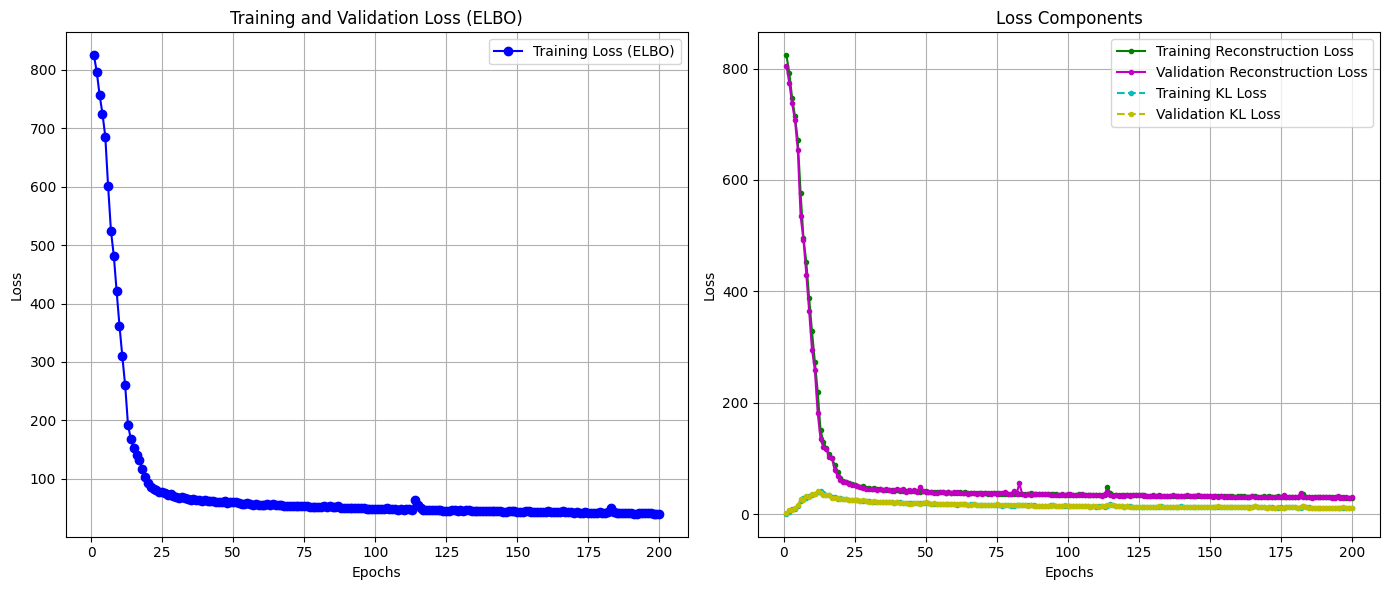

In [55]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Create a graph of the trend of loss metrics during training.

    Args:
        history (keras.callbacks.History): The object returned by model.fit().
    """

    loss = history.history.get('total_loss')
    val_loss = history.history.get('val_loss')

    recon_loss = history.history.get('reconstruction_loss')
    val_recon_loss = history.history.get('val_reconstruction_loss')

    kl_loss = history.history.get('kl_loss')
    val_kl_loss = history.history.get('val_kl_loss')

    epochs = range(1, len(loss) + 1)

    # creation of igure with subplots
    plt.figure(figsize=(14, 6))

    # 1. total loss (ELBO) graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss (ELBO)')
    if val_loss:
        plt.plot(epochs, val_loss, 'ro-', label='Validation Loss (ELBO)')
    plt.title('Training and Validation Loss (ELBO)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Loss components graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs, recon_loss, 'g.-', label='Training Reconstruction Loss')
    if val_recon_loss:
        plt.plot(epochs, val_recon_loss, 'm.-', label='Validation Reconstruction Loss')
    plt.plot(epochs, kl_loss, 'c.--', label='Training KL Loss')
    if val_kl_loss:
        plt.plot(epochs, val_kl_loss, 'y.--', label='Validation KL Loss')
    plt.title('Loss Components')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

The loss appears to drop drastically with the increase of epochs, reaching a simil-plateau at the end of the graph. Probably more epochs would better the performance, but not in a relevant way

**QUALITATIVE FEEDBACK**

Second, I'll plot some images reconstruction in order to evaluate them by eyes, this is done practically for personal interest, the performance is not changed, and the model it's not lowed down by this.

I also define the function to plot the latent space if it has an appropriate dimension (2)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
(787, 16)
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(787, 28, 28, 11)


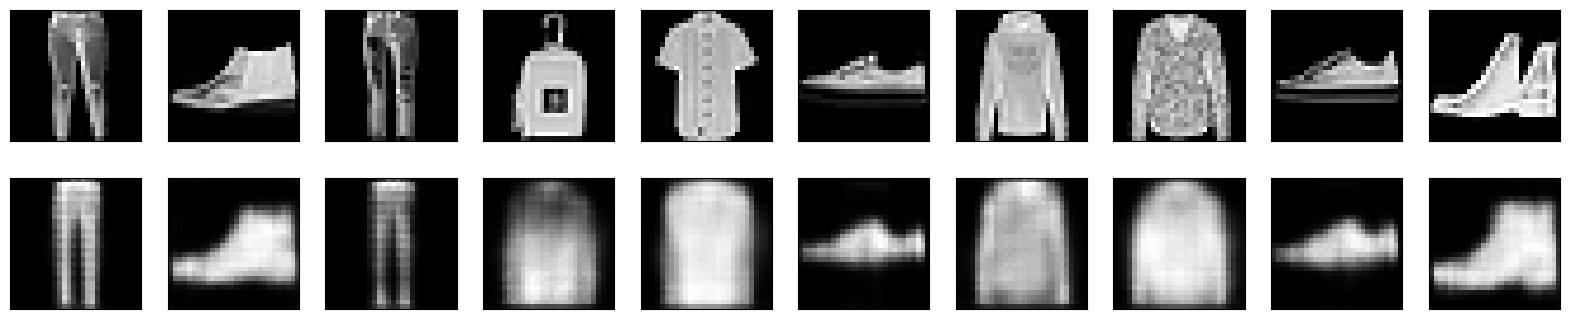

In [28]:
import matplotlib.pyplot as plt

def plot_imgs(original, decoded_imgs, n=10):
  # n  How many digits we will display
  plt.figure(figsize=(20, 4))
  for i in range(n):
      # Display original - extract the first channel
      ax = plt.subplot(2, n, i + 1)
      plt.imshow(original[i, :, :, 0].reshape(28, 28)) # Select the first channel
      plt.gray()
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)

      # Display reconstruction - extract the first channel
      ax = plt.subplot(2, n, i + 1 + n)
      plt.imshow(decoded_imgs[i, :, :, 0].reshape(28, 28)) # Select the first channel
      plt.gray()
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)
  plt.show()

_, _, z_test = final_vae.getEncodedImage(x_test)
print(z_test.shape)

decoded_imgs = final_vae.getDecodedImage(z_test)
print(decoded_imgs.shape)
plot_imgs(x_test, decoded_imgs, n=10)

Generating 10 new images from a 16-D latent space...


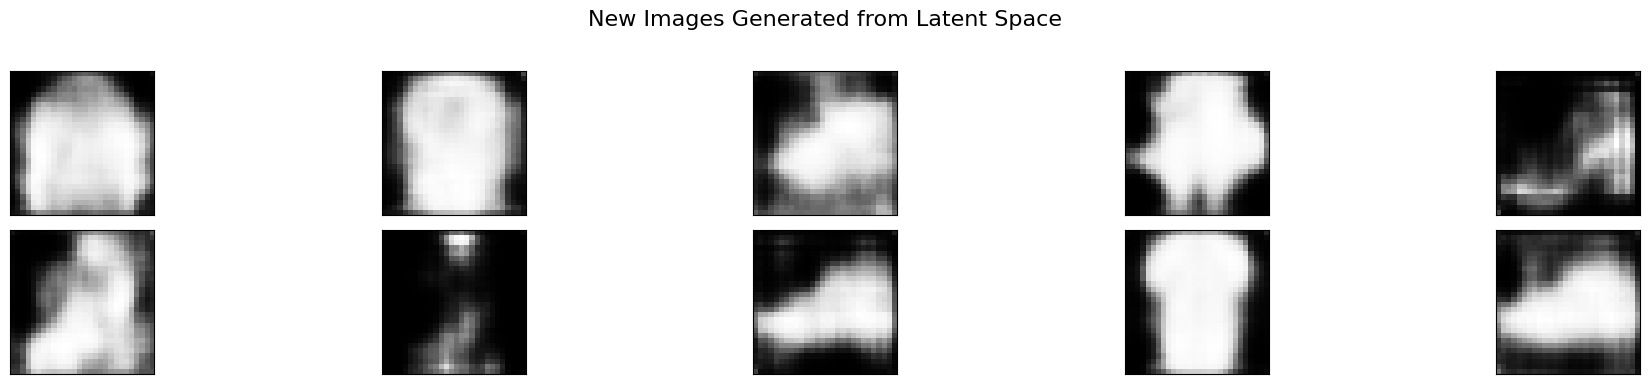

In [35]:
def generate_and_plot_images(vae, n=10, figsize=(20, 4)):

    # Get the decoder and the latent dimension from the VAE model
    decoder = vae.decoder
    # Fix: Access the shape from the layer's output tensor
    latent_dim = vae.encoder.get_layer("z_mean").output.shape[-1]

    # 1. Sample 'n' random points from the N-dimensional latent space prior.
    #    The prior is a standard normal distribution.
    random_latent_vectors = np.random.normal(size=(n, latent_dim))

    # 2. Use the decoder to generate the 11-channel output tensors from these points.
    generated_tensors = decoder.predict(random_latent_vectors, verbose=0)

    # 3. Extract the image channel (the first channel) for visualization.
    #    The output tensor shape is (n, 28, 28, 11). We select the first channel.
    generated_images = generated_tensors[:, :, :, 0]

    # --- Plotting the Results ---
    print(f"Generating {n} new images from a {latent_dim}-D latent space...")
    plt.figure(figsize=figsize)
    plt.suptitle("New Images Generated from Latent Space", fontsize=16)

    for i in range(n):
        # Determine the grid size for the plot
        # For example, for n=10, it creates a 2x5 grid.
        ax = plt.subplot(2, (n + 1) // 2, i + 1)

        # Display the image
        plt.imshow(generated_images[i], cmap="Greys_r")

        # Clean up the axes
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()


generate_and_plot_images(final_vae, n=10)